In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [2]:
DATA_PATH = '../data/processed/heart_processed.csv' 
SCALER_PATH = '../output/heart_disease_scaler.joblib'
MODEL_SAVE_PATH = '../output/heart_cluster_model.joblib'

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
target_col = 'HeartDisease' if 'HeartDisease' in df.columns else 'target'
X = df.drop(columns=[target_col])

In [5]:
scaler = joblib.load(SCALER_PATH)
X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [6]:
inertia, silhouette_scores = [], []
K_range = range(2, 8)

In [7]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

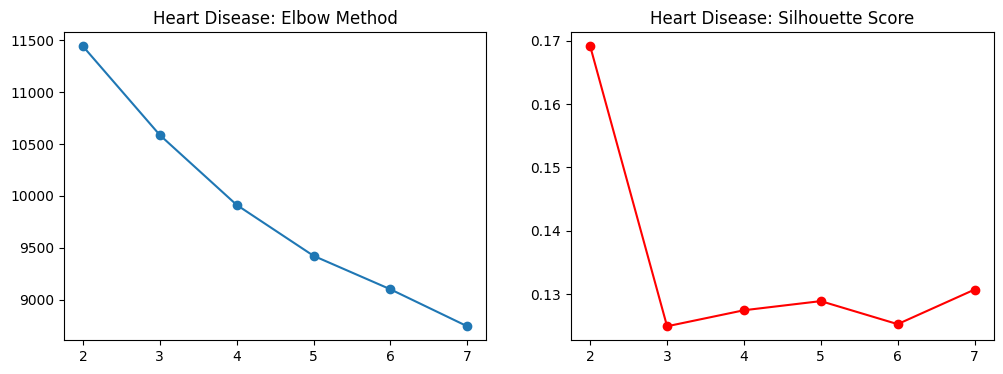

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Heart Disease: Elbow Method')
axes[1].plot(K_range, silhouette_scores, marker='o', color='red')
axes[1].set_title('Heart Disease: Silhouette Score')
plt.show()

In [9]:
OPTIMAL_K = 4 
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled_df)

In [10]:
cluster_centroids = df.groupby('Cluster').mean()
print("\n--- Heart Disease Profiles ---")
display(cluster_centroids)


--- Heart Disease Profiles ---


,Age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Cluster,,,,,,,,,,,,,,
0,58.209205,0.192469,1.284519,134.364017,261.543933,0.000000,0.502092,150.631799,0.112971,0.680335,1.439331,0.330544,2.037657,0.794979
1,57.719595,0.827703,0.185811,133.655405,255.033784,0.054054,0.429054,128.324324,0.756757,2.097297,0.929054,1.243243,2.608108,0.084459
2,47.859551,0.904494,1.216292,125.390449,227.688202,0.008427,0.668539,164.867978,0.140449,0.542416,1.721910,0.469101,2.342697,0.682584
3,57.910448,0.746269,1.276119,138.716418,246.970149,1.000000,0.432836,150.477612,0.328358,0.908955,1.402985,1.186567,2.156716,0.507463


In [11]:
joblib.dump(final_kmeans, MODEL_SAVE_PATH)

['../output/heart_cluster_model.joblib']